In [25]:
from unittest.mock import inplace

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.ma.extras import column_stack

In [26]:
cars_full = pd.read_csv("../datasets/cars/Car_details_v3.csv")

In [27]:
cars_full.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First Owner,17.3 km/kg,1061 CC,57.5 bhp,"7.8@ 4,500(kgm@ rpm)",5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.1 kmpl,796 CC,37 bhp,59Nm@ 2500rpm,4.0
8,Toyota Etios VXD,2011,350000,90000,Diesel,Individual,Manual,First Owner,23.59 kmpl,1364 CC,67.1 bhp,170Nm@ 1800-2400rpm,5.0
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,Manual,First Owner,20.0 kmpl,1399 CC,68.1 bhp,160Nm@ 2000rpm,5.0


In [28]:
cars_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [29]:
cars_full.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [30]:
cars_full.dropna(inplace=True)

In [31]:
cars_full.info()

<class 'pandas.DataFrame'>
Index: 7906 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           7906 non-null   str    
 1   year           7906 non-null   int64  
 2   selling_price  7906 non-null   int64  
 3   km_driven      7906 non-null   int64  
 4   fuel           7906 non-null   str    
 5   seller_type    7906 non-null   str    
 6   transmission   7906 non-null   str    
 7   owner          7906 non-null   str    
 8   mileage        7906 non-null   str    
 9   engine         7906 non-null   str    
 10  max_power      7906 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7906 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 864.7 KB


In [32]:
cars_encoded = pd.get_dummies(cars_full, columns=['fuel', 'seller_type', 'transmission', 'owner'])

In [33]:
cars_encoded["mileage"] = pd.to_numeric(cars_encoded["mileage"].astype(str).str.extract(r"^\s*([0-9]*\.?[0-9]+)", expand=False), errors="coerce")
cars_encoded["engine"] = pd.to_numeric(cars_encoded["engine"].astype(str).str.extract(r"^\s*([0-9]*\.?[0-9]+)", expand=False), errors="coerce")
cars_encoded["max_power"] = pd.to_numeric(cars_encoded["max_power"].astype(str).str.extract(r"^\s*([0-9]*\.?[0-9]+)", expand=False), errors="coerce")

In [34]:
cars_encoded.head()

,name,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,fuel_CNG,...,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti Swift Dzire VDI,2014,450000,145500,23.40,1248,74.00,190Nm@ 2000rpm,5.0,False,...,False,True,False,False,True,True,False,False,False,False
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,21.14,1498,103.52,250Nm@ 1500-2500rpm,5.0,False,...,False,True,False,False,True,False,False,True,False,False
2,Honda City 2017-2020 EXi,2006,158000,140000,17.70,1497,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,False,...,False,True,False,False,True,False,False,False,False,True
3,Hyundai i20 Sportz Diesel,2010,225000,127000,23.00,1396,90.00,22.4 kgm at 1750-2750rpm,5.0,False,...,False,True,False,False,True,True,False,False,False,False
4,Maruti Swift VXI BSIII,2007,130000,120000,16.10,1298,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,False,...,False,True,False,False,True,True,False,False,False,False


In [35]:
cars_encoded['brand'] = cars_encoded['name'].str.split().str[0]
cars_encoded = cars_encoded.drop('name', axis=1)
cars_encoded = pd.get_dummies(cars_encoded, columns=['brand'], drop_first=True)
cars_encoded.drop(columns=["torque"], inplace=True)

In [36]:
cars_encoded.dtypes

year                              int64
selling_price                     int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                           float64
fuel_CNG                           bool
fuel_Diesel                        bool
fuel_LPG                           bool
fuel_Petrol                        bool
seller_type_Dealer                 bool
seller_type_Individual             bool
seller_type_Trustmark Dealer       bool
transmission_Automatic             bool
transmission_Manual                bool
owner_First Owner                  bool
owner_Fourth & Above Owner         bool
owner_Second Owner                 bool
owner_Test Drive Car               bool
owner_Third Owner                  bool
brand_Ashok                        bool
brand_Audi                         bool
brand_BMW                          bool
brand_Chevrolet                    bool


In [37]:
cars_encoded.isnull().sum()

year                            0
selling_price                   0
km_driven                       0
mileage                         0
engine                          0
max_power                       0
seats                           0
fuel_CNG                        0
fuel_Diesel                     0
fuel_LPG                        0
fuel_Petrol                     0
seller_type_Dealer              0
seller_type_Individual          0
seller_type_Trustmark Dealer    0
transmission_Automatic          0
transmission_Manual             0
owner_First Owner               0
owner_Fourth & Above Owner      0
owner_Second Owner              0
owner_Test Drive Car            0
owner_Third Owner               0
brand_Ashok                     0
brand_Audi                      0
brand_BMW                       0
brand_Chevrolet                 0
brand_Daewoo                    0
brand_Datsun                    0
brand_Fiat                      0
brand_Force                     0
brand_Ford    

In [38]:
from sklearn.model_selection import train_test_split

X = cars_encoded.drop(columns=["selling_price"])
y = cars_encoded.selling_price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
def add_features(df):
    out = df.copy()
    dataset_year = out.year.max()

    out["car_age"] = dataset_year - out["year"]
    out["km_per_year"] = out["km_driven"] / out["car_age"].clip(lower=1)
    out["power_to_engine"] = out["max_power"] / out["engine"].replace(0, np.nan)
    out["mileage_x_engine"] = out["mileage"] * out["engine"]

    if "owner_First Owner" in out.columns:
        out["is_first_owner"] = out["owner_First Owner"].astype(int)

    return out

X_train = add_features(X_train)
X_test = add_features(X_test)

X_train.drop(columns=["year"], inplace=True)
X_test.drop(columns=["year"], inplace=True)

In [40]:
train_df = X_train.copy()
train_df["selling_price"] = y_train

array([[<Axes: title={'center': 'km_driven'}>,
        <Axes: title={'center': 'mileage'}>,
        <Axes: title={'center': 'engine'}>],
       [<Axes: title={'center': 'max_power'}>,
        <Axes: title={'center': 'seats'}>,
        <Axes: title={'center': 'car_age'}>],
       [<Axes: title={'center': 'km_per_year'}>,
        <Axes: title={'center': 'power_to_engine'}>,
        <Axes: title={'center': 'mileage_x_engine'}>],
       [<Axes: title={'center': 'is_first_owner'}>,
        <Axes: title={'center': 'selling_price'}>, <Axes: >]],
      dtype=object)

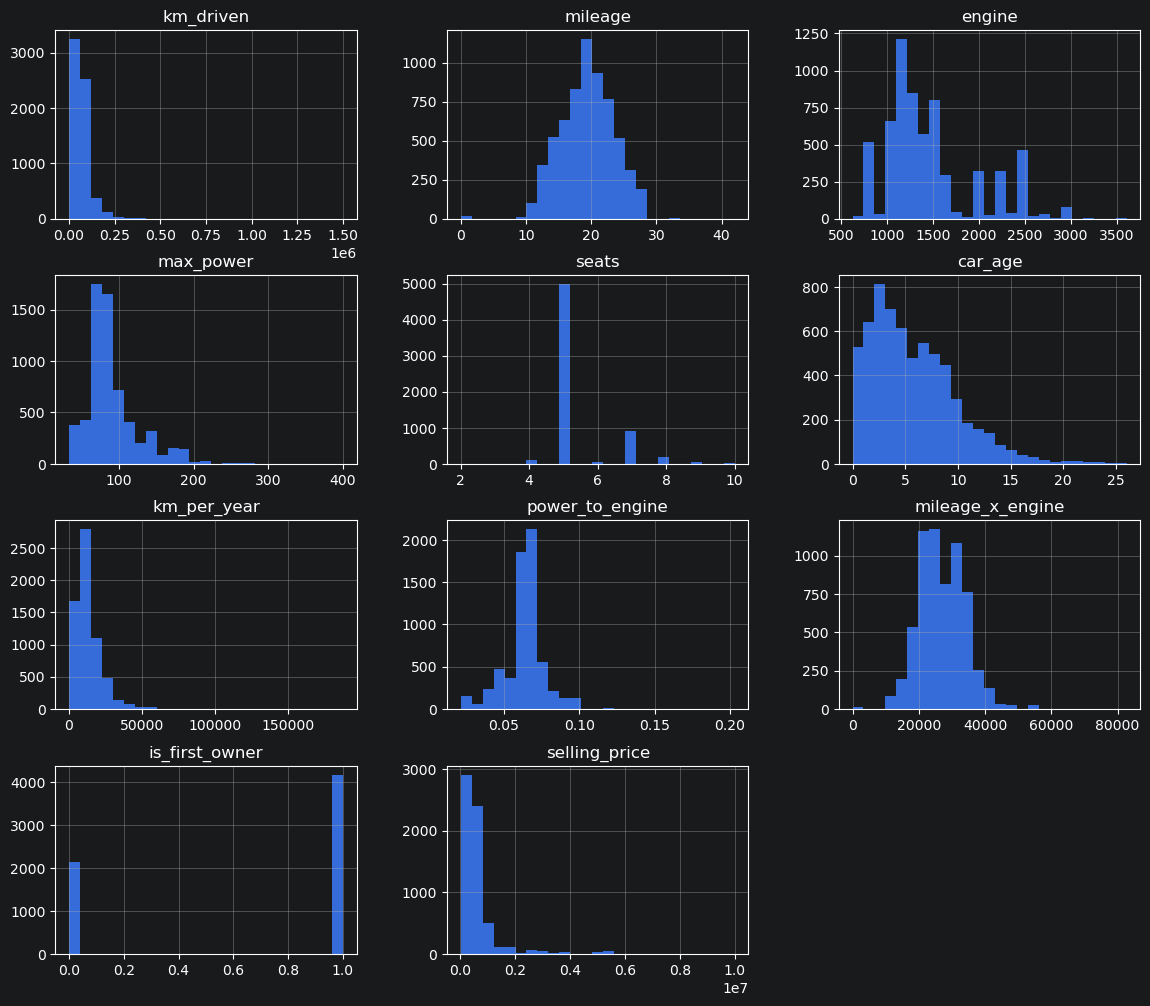

In [41]:
train_df.hist(bins=25, figsize=(14, 12))

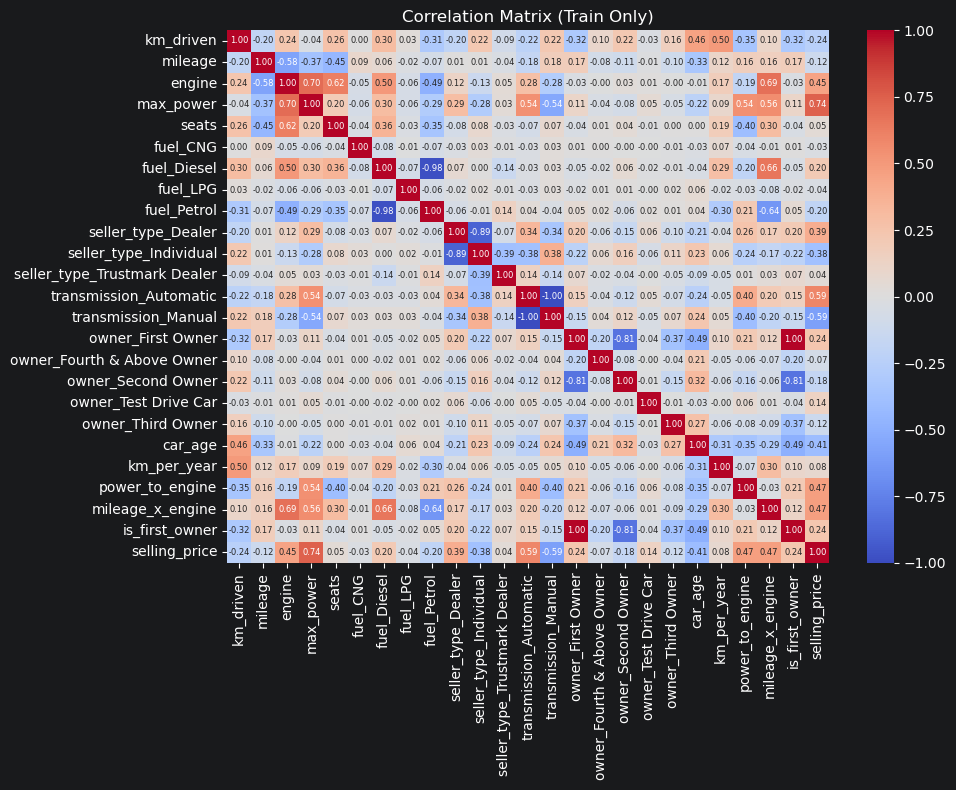

In [42]:
train_df["selling_price"] = y_train

cars_no_brand = train_df.loc[:, ~train_df.columns.str.startswith("brand_")]

corr_matrix = cars_no_brand.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, annot_kws={"size": 6})
plt.title("Correlation Matrix (Train Only)")
plt.tight_layout()
plt.show()

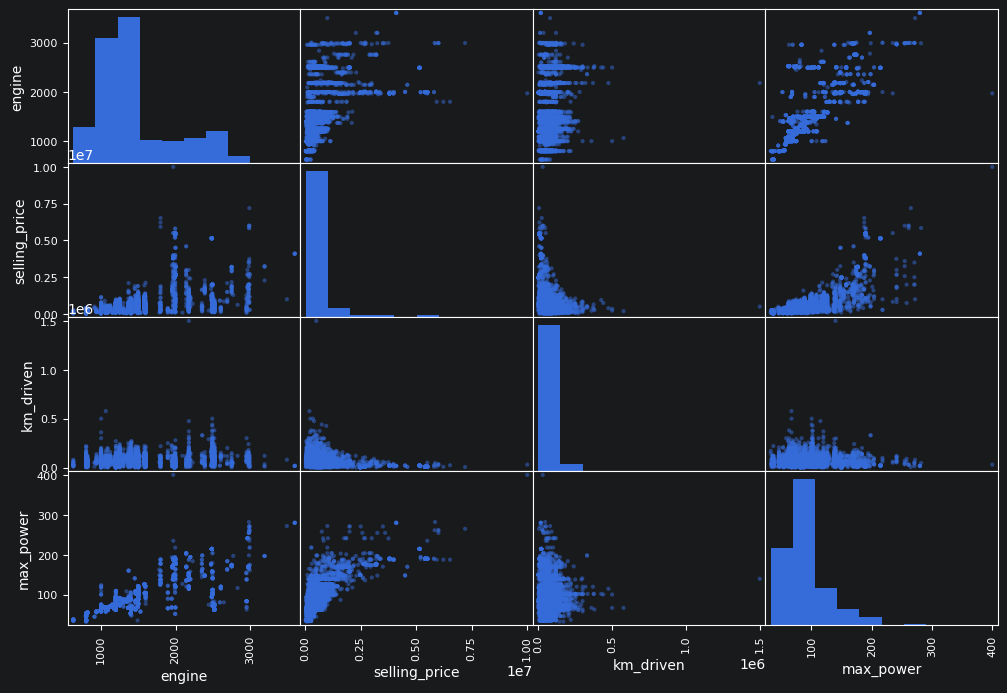

In [43]:
from pandas.plotting import scatter_matrix
attributes = ["engine", "selling_price", "km_driven", "max_power"]
scatter_matrix(train_df[attributes], figsize=(12, 8))
plt.show()

In [44]:
train_df.head()

,km_driven,mileage,engine,max_power,seats,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Dealer,...,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,car_age,km_per_year,power_to_engine,mileage_x_engine,is_first_owner,selling_price
3064,62900,18.90,998,67.1,5.0,False,False,False,True,False,...,False,False,False,False,14,4492.857143,0.067234,18862.20,1,135000
2522,95000,20.46,1461,83.8,5.0,False,True,False,False,False,...,False,False,False,False,7,13571.428571,0.057358,29892.06,1,490000
1819,38000,23.01,999,67.0,5.0,False,False,False,True,False,...,False,False,False,False,3,12666.666667,0.067067,22986.99,1,325000
6600,70000,15.40,2179,120.0,7.0,False,True,False,False,False,...,False,False,False,False,5,14000.000000,0.055071,33556.60,0,900000
7909,9500,21.50,1497,108.5,5.0,False,True,False,False,False,...,True,False,False,False,2,4750.000000,0.072478,32185.50,1,850000


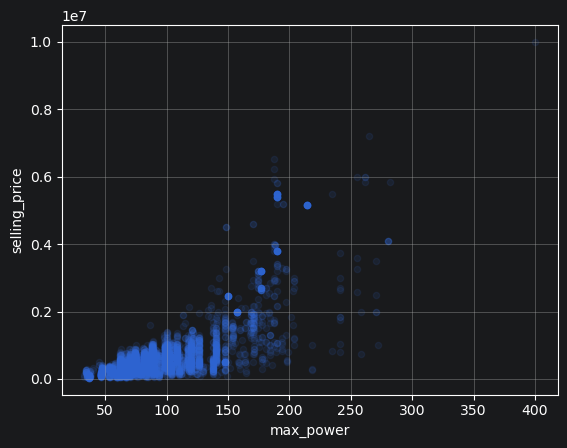

In [45]:
train_df.plot(kind="scatter", x="max_power", y="selling_price",
             alpha=0.1, grid=True)

plt.show()

In [68]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler

log_pipeline = make_pipeline(FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                             StandardScaler())

std_pipeline = make_pipeline(StandardScaler())

log_features = [
    "km_driven",
    "km_per_year",
    "max_power",
    "car_age"
]

scale_features = [
    "mileage",
    "power_to_engine",
    "mileage_x_engine",
    "engine"
]

passthrough_features = [
    "seats",
    "is_first_owner"
]

In [69]:
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([
    ("log_std",log_pipeline, log_features),
    ("std", std_pipeline, scale_features),
    ("pass", "passthrough", passthrough_features)
], remainder="drop")

In [73]:
X_transformed = preprocessing.fit_transform(X_train)
print(X_transformed.shape)

X_train_prepared = pd.DataFrame(
    X_transformed,
    columns=preprocessing.get_feature_names_out(),
    index=X_train.index
)

(6324, 10)


In [76]:
X_train_prepared.head(10)

,log_std__km_driven,log_std__km_per_year,log_std__max_power,log_std__car_age,std__mileage,std__power_to_engine,std__mileage_x_engine,std__engine,pass__seats,pass__is_first_owner
3064,0.225121,-1.285831,-0.706960,1.565129,-0.123214,0.283757,-1.185135,-0.917523,5.0,1.0
2522,0.695447,0.332530,-0.075256,0.494956,0.259743,-0.478490,0.384599,-0.003221,5.0,1.0
1819,-0.349717,0.231523,-0.711193,-0.685092,0.885731,0.270838,-0.598109,-0.915549,5.0,1.0
6600,0.347112,0.378048,0.948680,0.005192,-0.982414,-0.654984,0.906124,1.414639,7.0,0.0
7909,-1.930926,-1.204361,0.661035,-1.174855,0.515048,0.688465,0.710994,0.067870,5.0,1.0
1456,0.499425,-0.933803,-0.279319,1.565129,-0.417797,-0.883965,-0.098589,0.067870,5.0,0.0
4210,0.379245,-0.441232,-0.428979,0.874846,0.858728,-0.329004,0.197757,-0.423840,5.0,1.0
2835,0.171281,0.152367,0.080117,0.005192,1.489626,0.567694,0.654218,-0.423840,7.0,1.0
917,1.169887,0.279754,-0.432822,1.185239,-0.025020,-0.335188,-0.441644,-0.423840,5.0,0.0
6626,0.646379,0.269551,1.389279,0.494956,-1.056060,0.053396,0.813092,1.414639,7.0,1.0


array([[<Axes: title={'center': 'log_std__km_driven'}>,
        <Axes: title={'center': 'log_std__km_per_year'}>,
        <Axes: title={'center': 'log_std__max_power'}>],
       [<Axes: title={'center': 'log_std__car_age'}>,
        <Axes: title={'center': 'std__mileage'}>,
        <Axes: title={'center': 'std__power_to_engine'}>],
       [<Axes: title={'center': 'std__mileage_x_engine'}>,
        <Axes: title={'center': 'std__engine'}>,
        <Axes: title={'center': 'pass__seats'}>],
       [<Axes: title={'center': 'pass__is_first_owner'}>, <Axes: >,
        <Axes: >]], dtype=object)

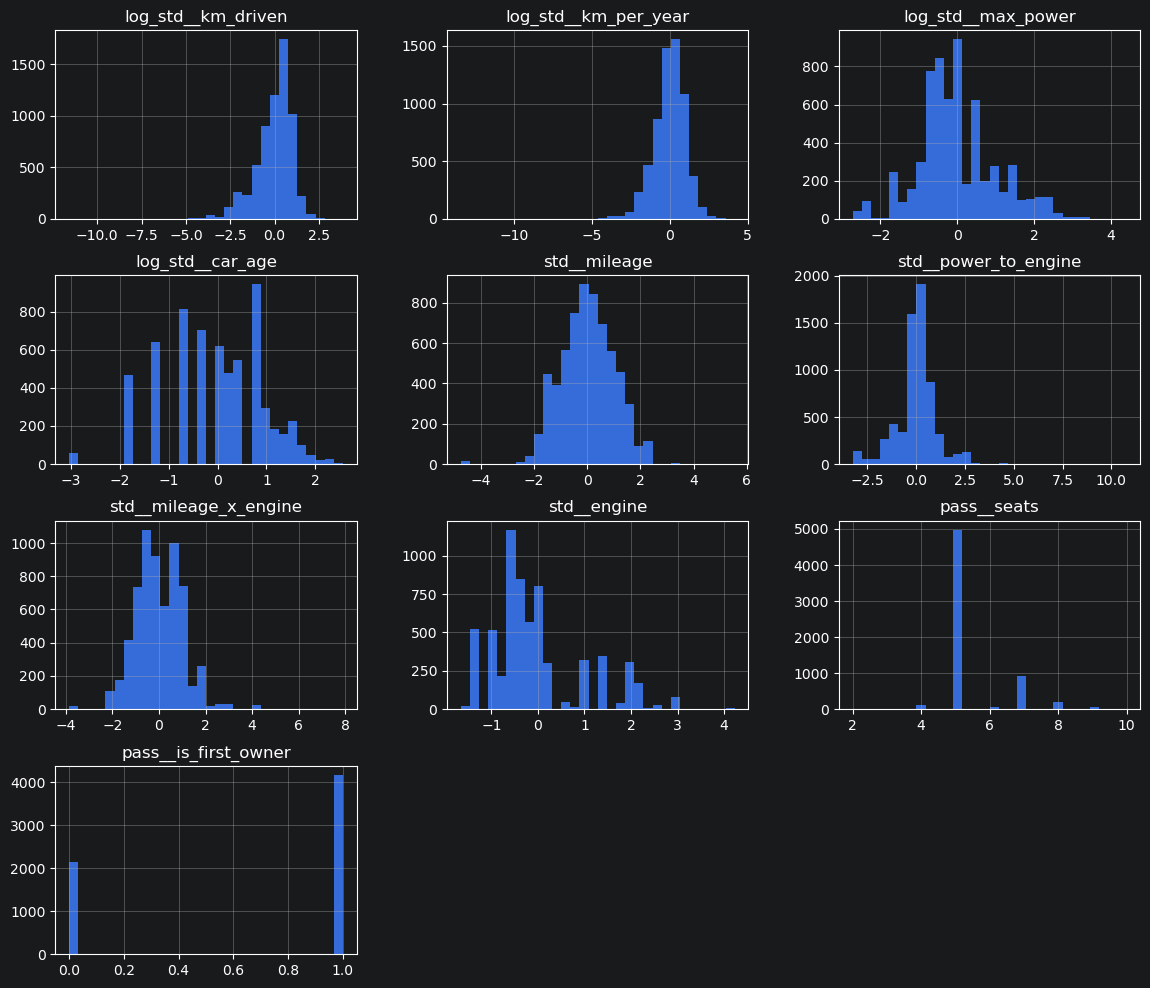

In [81]:
X_train_prepared.hist(bins=30, figsize=(14, 12))